# Timeseries Regression
Using Jena Climate Dataset

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.utils import timeseries_dataset_from_array

## Load and Prepare the Dataset

In [4]:
df = pd.read_csv('data/jena_climate_2009_2016.csv')
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [6]:
df.drop(columns='Date Time', inplace=True)

In [7]:
print('Dataset shape:', df.shape)

Dataset shape: (420451, 14)


In [8]:
temperature = df['T (degC)']
raw_data = df

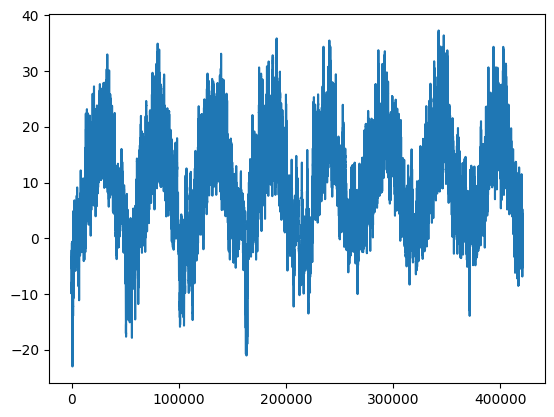

In [9]:
temperature.plot()
plt.show()

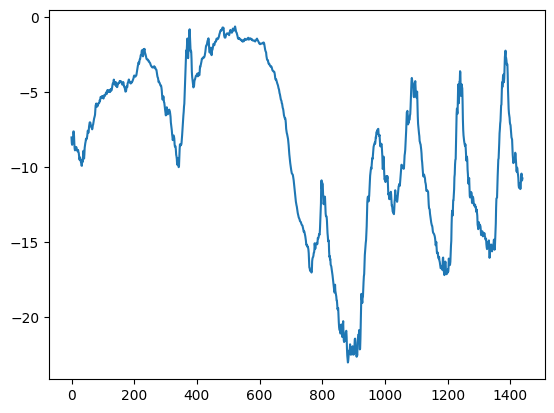

In [11]:
temperature[:1440].plot()
plt.show()

In [12]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

In [13]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [15]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

In [16]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


## Models

### Baseline Model

In [19]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std['T (degC)'] + mean['T (degC)']
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


### MLP

In [23]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras",
                                    save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 14.7941 - mae: 2.9050 - val_loss: 10.5536 - val_mae: 2.5564
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 9.0024 - mae: 2.3642 - val_loss: 10.4770 - val_mae: 2.5544
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.3557 - mae: 2.2763 - val_loss: 10.3415 - val_mae: 2.5460
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.9265 - mae: 2.2170 - val_loss: 10.2733 - val_mae: 2.5362
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.5912 - mae: 2.1688 - val_loss: 10.1573 - val_mae: 2.5296
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.3868 - mae: 2.1389 - val_loss: 10.1936 - val_mae: 2.5329
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.1583 - mae: 2.1053 - val_loss: 10.4245 - val_mae: 2.5610
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.0251 - mae: 2.0853 - val_loss: 10.2820 - val_mae: 2.5434
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/

In [24]:
model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 11.3291 - mae: 2.6422
Test MAE: 2.64


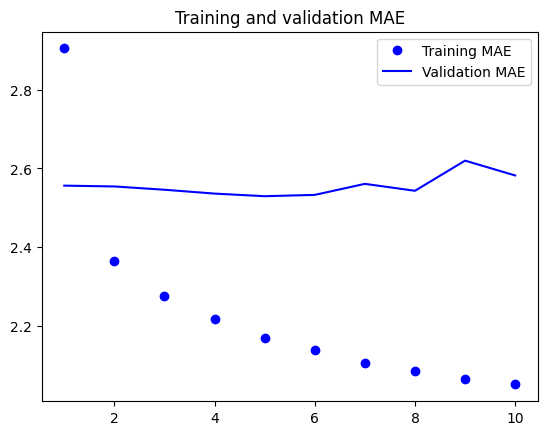

In [25]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### CNN Model

In [27]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras",
                                    save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 21.9773 - mae: 3.6337 - val_loss: 15.2115 - val_mae: 3.0907
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 14.1244 - mae: 2.9755 - val_loss: 15.1029 - val_mae: 3.0822
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 13.0012 - mae: 2.8473 - val_loss: 14.7558 - val_mae: 3.0467
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 12.2690 - mae: 2.7619 - val_loss: 14.6527 - val_mae: 3.0233
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 11.7264 - mae: 2.6980 - val_loss: 16.0165 - val_mae: 3.1611
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 11.3723 - mae: 2.6557 - val_loss: 15.1702 - val_mae: 3.0652
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 10.9640 - mae: 2.6076 - val_loss: 15.6920 - val_mae: 3.1075
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 10.7072 - mae: 2.5774 - val_loss: 15.1299 - val_mae: 3.0699
Epoch 9/10
819/819 ━━━━━━━━━━━━━━

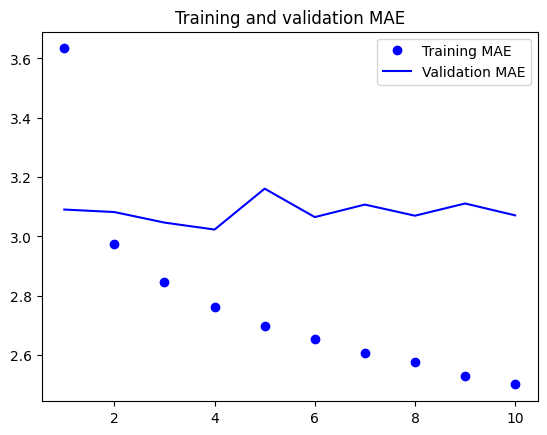

In [28]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [29]:
model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 15.7118 - mae: 3.1372
Test MAE: 3.14


In [30]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras",
                                    save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - loss: 43.6074 - mae: 4.8567 - val_loss: 17.3686 - val_mae: 3.0810
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 13.5340 - mae: 2.8008 - val_loss: 11.5868 - val_mae: 2.5725
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 10.5872 - mae: 2.5259 - val_loss: 10.3902 - val_mae: 2.4586
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 9.6697 - mae: 2.4248 - val_loss: 9.7244 - val_mae: 2.4026
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 9.2359 - mae: 2.3715 - val_loss: 9.4832 - val_mae: 2.3777
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 8.9096 - mae: 2.3305 - val_loss: 9.4543 - val_mae: 2.3756
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 8.6848 - mae: 2.3047 - val_loss: 10.0688 - val_mae: 2.4359
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - loss: 8.4896 - mae: 2.2825 - val_loss: 9.9963 - val_mae: 2.4290
Epoch 9/10
819/819 ━━━━━━━━━━━━━━

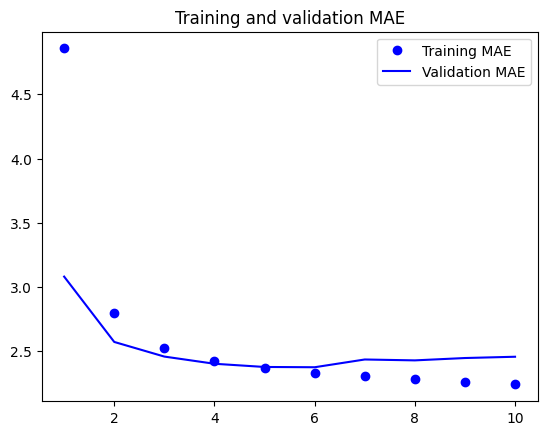

In [31]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()